In [24]:
from typing import Annotated
import operator,json
from typing import TypedDict, Annotated, Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,END,START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from langchain_core.messages import BaseMessage, ToolMessage

In [25]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.3-70b-versatile")

In [26]:
llm.invoke("hi")

AIMessage(content="It's nice to meet you. Is there something I can help you with, or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 36, 'total_tokens': 60, 'completion_time': 0.051983385, 'completion_tokens_details': None, 'prompt_time': 0.014848553, 'prompt_tokens_details': None, 'queue_time': 0.26594894, 'total_time': 0.066831938}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0dfe-24e9-7920-b6f2-ca6525895f44-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 24, 'total_tokens': 60})

In [27]:
@tool
def multiply(first_number:int, second_number:int)->int:
    """multiply two integer number"""
    return first_number * second_number

In [28]:
multiply.invoke({"first_number":24,"second_number":364})

8736

In [29]:
search = TavilySearch(max_results=2)

In [30]:
search.invoke("who is a current president of USA?")

{'query': 'who is a current president of USA?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/President_of_the_United_States',
   'title': 'President of the United States - Wikipedia',
   'content': 'Donald Trump is the 47th and current president since January 20, 2025.',
   'score': 0.8729662,
   'raw_content': None},
  {'url': 'https://www.usa.gov/presidents',
   'title': 'Presidents, vice presidents, and first ladies - USAGov',
   'content': 'The 47th and current president of the United States is Donald John Trump. ... Ask USA.gov a question at. 1-844-USAGOV1 (1-844-872-4681).',
   'score': 0.8682137,
   'raw_content': None}],
 'response_time': 0.59,
 'request_id': '90fdbe33-ae53-4826-a834-5a479014ccc2'}

In [31]:
tools=[search,multiply]

In [49]:
model_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

In [50]:
tool_mapping={tool.name: tool for tool in tools}

In [51]:
tool_mapping

{'tavily_search': TavilySearch(max_results=2, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None)),
 'multiply': StructuredTool(name='multiply', description='multiply two integer number', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000023A63252F20>)}

In [52]:
response = model_with_tools.invoke("who is a current president of USA?")
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'b3fjznj47', 'function': {'arguments': '{"query":"current president of USA","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 1738, 'total_tokens': 1763, 'completion_time': 0.075860613, 'completion_tokens_details': None, 'prompt_time': 0.129582455, 'prompt_tokens_details': None, 'queue_time': 0.052073473, 'total_time': 0.205443068}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0dff-ef50-7a13-9535-09b9463ae18b-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'current president of USA', 'topic': 'news'}, 'id': 'b3fjznj47', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1738, 'output_tokens': 25, 'total_tokens': 1763})

In [53]:
tool_details=response.additional_kwargs.get("tool_calls")
tool_details

[{'id': 'b3fjznj47',
  'function': {'arguments': '{"query":"current president of USA","topic":"news"}',
   'name': 'tavily_search'},
  'type': 'function'}]

In [54]:
tool_details[0]["function"]["name"]

'tavily_search'

In [55]:
tool_details[0]["function"]["arguments"]

'{"query":"current president of USA","topic":"news"}'

In [56]:
json.loads(tool_details[0]["function"]["arguments"])

{'query': 'current president of USA', 'topic': 'news'}

In [57]:
tool_mapping[tool_details[0]["function"]["name"]].invoke(json.loads(tool_details[0]["function"]["arguments"]))

{'query': 'current president of USA',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.usatoday.com/story/news/2026/06/23/white-house-renovations-continue-with-restoration-of-historic-columns/90655701007/',
   'title': 'White House renovations continue: What’s the latest work being done? - USA Today',
   'score': 0.32882085,
   'published_date': 'Tue, 23 Jun 2026 14:06:00 GMT',
   'content': '# White House renovations continue: What’s the latest work being done? President Donald Trump has already orchestrated makeovers of several iconic parts of the White House, including the Rose Garden lawn and East Wing, and now renovations are underway on the building\'s iconic columns at its front entrance. Reports of the new renovations began to surface late last week when construction crews were photographed performing maintenance on the White House columns, which were built in 1830. The White House confirmed the construction work in a statement to 

In [58]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [59]:
def invoke_model(state: AgentState):
    messages = state["messages"]
    return {"messages": [model_with_tools.invoke(messages)]}

In [60]:
def invoke_tool(state: AgentState):
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[0]       # modern: already parsed dict

    print(f"Selected tool: {tool_call['name']}")

    if tool_call["name"] == "tavily_search":     # fixed: was "search"
        user_input = input("[y/n] continue with expensive web search? ")
        if user_input.strip().lower() == "n":
            raise Exception("web search discarded by user")

    result = tool_mapping[tool_call["name"]].invoke(tool_call["args"])

    return {
        "messages": [
            ToolMessage(
                content=str(result),
                tool_call_id=tool_call["id"],
            )
        ]
    }

In [61]:
def router(state):
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and len(last.tool_calls):
        return "tool"
    return "end"

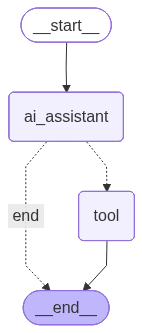

In [62]:
graph = StateGraph(AgentState) ### StateGraph with AgentState

graph.add_node("ai_assistant", invoke_model)
graph.add_node("tool", invoke_tool)
graph.add_conditional_edges("ai_assistant", router, {"tool": "tool","end": END,})
graph.add_edge("tool", END)
graph.set_entry_point("ai_assistant")
     
app = graph.compile()
     

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [63]:
for s in app.stream({"messages": ["what is multiplication of 23 and 46?"]}):
    print(list(s.values())[0])
    print("----")

{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'mw3we0n2z', 'function': {'arguments': '{"first_number":23,"second_number":46}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 1740, 'total_tokens': 1761, 'completion_time': 0.060112463, 'completion_tokens_details': None, 'prompt_time': 0.090212123, 'prompt_tokens_details': None, 'queue_time': 0.052029203, 'total_time': 0.150324586}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0dff-f9a4-7532-9699-83719125b912-0', tool_calls=[{'name': 'multiply', 'args': {'first_number': 23, 'second_number': 46}, 'id': 'mw3we0n2z', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1740, 'output_tokens': 21, 'total_tokens': 1761})]}
----
Selected tool: multiply
{'messages':

In [64]:
for s in app.stream({"messages": ["who is upcoming president of USA?"]}):
    print(list(s.values())[0])
    print("----")

{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '844h67ytk', 'function': {'arguments': '{"query":"upcoming president of USA","search_depth":"advanced","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 1737, 'total_tokens': 1770, 'completion_time': 0.101163275, 'completion_tokens_details': None, 'prompt_time': 0.093958774, 'prompt_tokens_details': None, 'queue_time': 0.090673113, 'total_time': 0.195122049}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0dff-fe57-7e31-b13e-646f80aa5559-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'upcoming president of USA', 'search_depth': 'advanced', 'topic': 'news'}, 'id': '844h67ytk', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1

In [65]:
for s in app.stream({"messages": ["what is the total amount of money exist over the earth?"]}):
    print(list(s.values())[0])
    print("----")


{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'vfrzn7bm2', 'function': {'arguments': '{"query":"total amount of money in the world","search_depth":"advanced","topic":"finance"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 1742, 'total_tokens': 1777, 'completion_time': 0.107196454, 'completion_tokens_details': None, 'prompt_time': 0.505744767, 'prompt_tokens_details': None, 'queue_time': 0.041938815, 'total_time': 0.612941221}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0e00-1646-75f2-abe3-fff954c7b54b-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'total amount of money in the world', 'search_depth': 'advanced', 'topic': 'finance'}, 'id': 'vfrzn7bm2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_met

### LG built-in classes

In [89]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.3-70b-versatile")

In [90]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

In [91]:
tavily=TavilySearch()

In [92]:
tools = [tavily]

In [93]:
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

In [94]:
def ai_assistant(state: AgentState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [95]:
memory = MemorySaver()

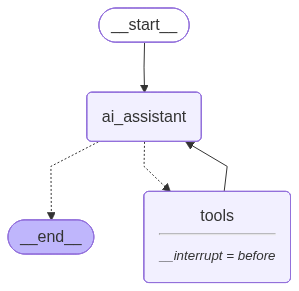

In [96]:
graph = StateGraph(AgentState)
graph.add_node("ai_assistant", ai_assistant)
tool_node = ToolNode(tools=tools)
graph.add_node("tools", tool_node)
graph.add_edge(START, "ai_assistant")
graph.add_conditional_edges("ai_assistant", 
    tools_condition,)
graph.add_edge("tools", "ai_assistant")

app = graph.compile(checkpointer=memory,
    interrupt_before=["tools"])

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [97]:
user_input = "what is current a capital of india?"
config = {"configurable": {"thread_id": "1"}}

In [98]:
events = app.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)

In [99]:
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

what is current a capital of india?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (2r6s7bwep)
 Call ID: 2r6s7bwep
  Args:
    query: current capital of India
    topic: general


In [100]:
snapshot = app.get_state(config)
print(snapshot)
print(snapshot.next)

StateSnapshot(values={'messages': [HumanMessage(content='what is current a capital of india?', additional_kwargs={}, response_metadata={}, id='0ce86455-0cbb-4e7e-96ec-d7b9abf31f31'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '2r6s7bwep', 'function': {'arguments': '{"query":"current capital of India","topic":"general"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 1681, 'total_tokens': 1706, 'completion_time': 0.086785045, 'completion_tokens_details': None, 'prompt_time': 0.179193636, 'prompt_tokens_details': None, 'queue_time': 1.045267836, 'total_time': 0.265978681}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0e0c-37ba-72c3-9c6f-d8a0039f9752-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'current capital of India', 

In [101]:
last_message=snapshot.values["messages"][-1]

In [102]:
last_message.tool_calls   

[{'name': 'tavily_search',
  'args': {'query': 'current capital of India', 'topic': 'general'},
  'id': '2r6s7bwep',
  'type': 'tool_call'}]

In [103]:
events = app.stream(None, config, stream_mode="values")

In [104]:
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search (2r6s7bwep)
 Call ID: 2r6s7bwep
  Args:
    query: current capital of India
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "current capital of India", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.quora.com/Which-one-is-the-capital-of-India", "title": "Which one is the capital of India? - Quora", "content": "New Delhi is the current capital of India. Image source: Google ... Financial Capital : Mumbai. Religious Capital : Varanasi. Educational Capital", "score": 0.8958969, "raw_content": null}, {"url": "https://verandarace.com/blog/states-union-territories-capitals-of-india", "title": "States, Union Territories and Capitals of India 2025", "content": "New Delhi serves as the capital of India and is itself a union territory. The other union territories

In [105]:
user_input = "what is a weather there?"

config = {"configurable": {"thread_id": "1"}}

In [106]:
app.invoke({"messages": [("user", user_input)]}, config)

{'messages': [HumanMessage(content='what is current a capital of india?', additional_kwargs={}, response_metadata={}, id='0ce86455-0cbb-4e7e-96ec-d7b9abf31f31'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '2r6s7bwep', 'function': {'arguments': '{"query":"current capital of India","topic":"general"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 1681, 'total_tokens': 1706, 'completion_time': 0.086785045, 'completion_tokens_details': None, 'prompt_time': 0.179193636, 'prompt_tokens_details': None, 'queue_time': 1.045267836, 'total_time': 0.265978681}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0e0c-37ba-72c3-9c6f-d8a0039f9752-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'current capital of India', 'topic': 'general'}

In [107]:
result = app.invoke(None, config)

# last message is the final AIMessage with the weather answer
print(result["messages"][-1].content)

# or pretty print the whole conversation from this turn
for msg in result["messages"]:   # last 3: tool call, tool result, final answer
    msg.pretty_print()

The current weather in New Delhi is moderate or heavy rain with thunder, with a temperature of 40.1°C (104.2°F) and a feels-like temperature of 40.2°C (104.3°F). The wind is blowing at 13.9 mph (22.3 kph) from the west-southwest, and the humidity is 34%. There is a 1% chance of rain, and the UV index is 0.5. The dew point is 15.5°C (59.9°F), and the visibility is 3.5 km (2.0 miles).
================================ Human Message =================================

what is current a capital of india?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (2r6s7bwep)
 Call ID: 2r6s7bwep
  Args:
    query: current capital of India
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "current capital of India", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.quora.com/Which-one-is-the-capital-of-India", "title": "Whic